## More stats to validate the results

In [ ]:
# divided
# /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/divided/176x88x48/variable_voxel_distance/mean_two_landmarks/straight_model/learning_rate/0.0001/19Nov2025-10:01:33-trainID-2

In [1]:
# the data i needed, final results
## cropped size (63, 50, 61)
## fc - org - /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/09Jul2024-12:12:48-trainID-33.3
## fc - retrain - /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/19Nov2025-13:17:24-trainID-33.3
## final_Y_test_pred.npy, Y_test_true.npy, res_test.npy, best_val_Y_CTPre14_pred.npy, Y_CTPre14_true.npy, res_CTPre14.npy
## dsnt - "/data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/u_net_dsnt/turner_results/random_grid_0/14Aug2024-04:36:02-trainID-13.1"
import os
import numpy as np

down_net_FC_ret_dir = "/data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/19Nov2025-13:17:24-trainID-33.3"
u_net_DSNT_ret_dir = "/data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/u_net_dsnt/turner_results/random_grid_0/14Aug2024-04:36:02-trainID-13.1"

# down net FC results, test and extra CTPre14
down_net_FC_y_test_true = np.load(os.path.join(down_net_FC_ret_dir, "Y_test_true.npy"))
down_net_FC_y_test_pred = np.load(os.path.join(down_net_FC_ret_dir, "final_Y_test_pred.npy"))
down_net_FC_res_test = np.load(os.path.join(down_net_FC_ret_dir, "res_test.npy"))

down_net_FC_y_CTPre14_true = np.load(os.path.join(down_net_FC_ret_dir, "Y_CTPre14_true.npy"))
down_net_FC_y_CTPre14_pred = np.load(os.path.join(down_net_FC_ret_dir, "best_val_Y_CTPre14_pred.npy"))
down_net_FC_res_CTPre14 = np.load(os.path.join(down_net_FC_ret_dir, "res_CTPre14.npy"))
down_net_FC_length_CTPre14 = np.load(os.path.join(down_net_FC_ret_dir, "length_CTPre14.npy"))

# U-Net DSNT results, test and extra CTPre14
u_net_DSNT_y_test_true = np.load(os.path.join(u_net_DSNT_ret_dir, "Y_test_true.npy"))
u_net_DSNT_y_test_pred = np.load(os.path.join(u_net_DSNT_ret_dir, "final_Y_test_pred.npy"))
u_net_DSNT_res_test = np.load(os.path.join(u_net_DSNT_ret_dir, "res_test.npy"))

u_net_DSNT_y_CTPre14_true = np.load(os.path.join(u_net_DSNT_ret_dir, "Y_CTPre14_true.npy"))
u_net_DSNT_y_CTPre14_pred = np.load(os.path.join(u_net_DSNT_ret_dir, "best_val_Y_CTPre14_pred.npy"))
u_net_DSNT_res_CTPre14 = np.load(os.path.join(u_net_DSNT_ret_dir, "res_CTPre14.npy"))
# u_net_DSNT_length_CTPre14 = np.load(os.path.join(u_net_DSNT_ret_dir, "length_CTPre14.npy"))

In [2]:
# need to swap the dsnt Y to real world coords
(row_size, column_size, slice_size) = (63, 50, 61)
# y_dataset = (2 * y_dataset - [column_size + 1, row_size + 1, slice_size + 1]) / [column_size, row_size, slice_size]
# res_dataset = (res_dataset / [2 / column_size, 2 / row_size, 2 / slice_size])
u_net_DSNT_y_CTPre14_pred_015 = (u_net_DSNT_y_CTPre14_pred * [column_size, row_size, slice_size] + [(column_size + 1), (row_size + 1), (slice_size + 1)]) / 2
u_net_DSNT_y_CTPre14_true_015 = (u_net_DSNT_y_CTPre14_true * [column_size, row_size, slice_size] + [(column_size + 1), (row_size + 1), (slice_size + 1)]) / 2   
u_net_DSNT_res_CTPre14_015 = u_net_DSNT_res_CTPre14 * [2 / column_size, 2 / row_size, 2 / slice_size]

In [2]:
patient_names_14 = ['CD', 'DN', 'GS', 'HME', 'LY', 'MG', 'MM', 'NJ', 'RM', 'SL', 'TA', 'TG', 'VPR', 'YJ']

In [4]:
# flip the pts, test the true pts first
def transform_pts(pts, vol_shape, length, patient_names):
    try_vis_pts = np.copy(pts)

    for idx in range(len(patient_names)):
        right_ear_idx = 2 * idx + 1
        try_vis_pts[right_ear_idx, :, [0]] = np.ones(try_vis_pts[right_ear_idx, :, [0]].shape) * (vol_shape[1] + 1) - try_vis_pts[right_ear_idx, :, [0]]

    try_vis_pts = try_vis_pts + length
    return try_vis_pts

vol_shape = (row_size, column_size, slice_size)

y_CTPer_true_org_index = transform_pts(down_net_FC_y_CTPre14_true, vol_shape, down_net_FC_length_CTPre14, patient_names_14)
down_net_FC_y_CTPre14_pred_org_index = transform_pts(down_net_FC_y_CTPre14_pred, vol_shape, down_net_FC_length_CTPre14, patient_names_14)

In [ ]:
print("Visualization pts prepared.")
print("Down net FC CTPre14 true pts: ", y_CTPer_true_org_index[:8])
print("Down net FC CTPre14 pred pts: ", down_net_FC_y_CTPre14_pred_org_index[:8])

In [19]:
import pandas as pd
from pathlib import Path
from typing import Optional, Dict, List, Union

base_dir = "/data/gpfs/projects/punim1836/Data/processed/CT_Pre_add14"

landmarks = ["LLSCC ant", "LLSCC post", "RLSCC ant", "RLSCC post"]

for idx in range(len(patient_names_14)):
    # Build per-patient records
    per_patient: List[Dict[str, Union[str, float, int]]] = []
    pts = np.copy(down_net_FC_y_CTPre14_pred_org_index[idx*2:idx*2+2, :, :])
    per_patient.append({"name": landmarks[0], "x": pts[0, 0, 0], "y": pts[0, 0, 1], "z": pts[0, 0, 2]})
    per_patient.append({"name": landmarks[1], "x": pts[0, 1, 0], "y": pts[0, 1, 1], "z": pts[0, 1, 2]})
    per_patient.append({"name": landmarks[2], "x": pts[1, 0, 0], "y": pts[1, 0, 1], "z": pts[1, 0, 2]})
    per_patient.append({"name": landmarks[3], "x": pts[1, 1, 0], "y": pts[1, 1, 1], "z": pts[1, 1, 2]})

    pat_name = patient_names_14[idx]
    save_path = Path(f"{down_net_FC_ret_dir}/CT_Pre14_vis/{pat_name}_landmarks.csv")
    save_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(per_patient, columns=["name", "x", "y", "z"]).to_csv(save_path, index=False)
    print(f"Saved: {save_path}")

Saved: /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/19Nov2025-13:17:24-trainID-33.3/CT_Pre14_vis/CD_landmarks.csv
Saved: /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/19Nov2025-13:17:24-trainID-33.3/CT_Pre14_vis/DN_landmarks.csv
Saved: /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/19Nov2025-13:17:24-trainID-33.3/CT_Pre14_vis/GS_landmarks.csv
Saved: /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/19Nov2025-13:17:24-trainID-33.3/CT_Pre14_vis/HME_landmarks.csv
Saved: /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/n

In [ ]:
# find the maximum error in test set
# find the maximum error in test set (per-landmark, record patient/side/landmark)
def analyze_CTPre14_errors(
    y_true=None,
    y_pred=None,
    res_arr=None,
    patient_names=None,
    out_dir=None,
    default_voxel=0.15,
):
    """
    Compute per-landmark and per-patient 3D errors (mm) for CTPre14 results,
    save sorted landmark list and patient->landmark dict, and return results.

    Returns:
        entries_sorted: list of tuples (err_mm, patient, side, landmark, result_idx, landmark_idx)
        patient_sorted_by_max: dict mapping patient -> {side_landmark: err_mm, ...}, sorted by patient max desc
        res_flat: (n_results, 3) per-result voxel spacing used
    """
    # pick notebook globals if args not provided
    y_true = y_true if y_true is not None else globals().get("y_CTPre14_true")
    y_pred = y_pred if y_pred is not None else globals().get("y_CTPre14_pred")
    res_arr = res_arr if res_arr is not None else globals().get("res_CTPre14")
    patient_names = patient_names if patient_names is not None else globals().get("patient_names_14")
    out_dir = out_dir if out_dir is not None else (
        globals().get("ret_dir")
        or globals().get("down_net_FC_ret_dir")
        or globals().get("u_net_DSNT_ret_dir")
        or "."
    )

    if y_true is None or y_pred is None:
        raise ValueError("y_true and y_pred must be provided (or present in notebook globals).")

    t = np.asarray(y_true, float)
    p = np.asarray(y_pred, float)

    if t.shape != p.shape:
        raise ValueError(f"y_true/pred shape mismatch: {t.shape} vs {p.shape}")
    if t.ndim != 3 or t.shape[1] != 2 or t.shape[2] != 3:
        raise ValueError(f"Unexpected shape for y_true/pred: {t.shape}")

    n_results = t.shape[0]
    if patient_names is None:
        raise ValueError("patient_names must be provided (or present in globals).")
    if n_results != 2 * len(patient_names):
        raise ValueError(f"Number of results ({n_results}) != 2 * len(patient_names) ({2*len(patient_names)})")

    # normalize res array to (n_results, 3)
    res_arr_np = np.asarray(res_arr)
    res_flat = np.squeeze(res_arr_np)
    if res_flat.ndim == 1 and res_flat.size == 3:
        res_flat = np.tile(res_flat, (n_results, 1))
    else:
        try:
            res_flat = res_flat.reshape(n_results, 3)
        except Exception:
            res_flat = np.full((n_results, 3), float(default_voxel), dtype=float)

    # build entries and per-patient dict
    entries = []
    patient_errors = {name: {} for name in patient_names}

    for r in range(n_results):
        patient_idx = r // 2
        patient = patient_names[patient_idx]
        side = "L" if (r % 2) == 0 else "R"
        for l_idx, landmark_name in enumerate(["ant", "post"]):
            diff_vox = t[r, l_idx] - p[r, l_idx]
            diff_mm = diff_vox * res_flat[r]
            err_mm = float(np.linalg.norm(diff_mm))
            entries.append((err_mm, patient, side, landmark_name, r, l_idx))
            patient_errors[patient][f"{side}_{landmark_name}"] = err_mm

    entries_sorted = sorted(entries, key=lambda x: x[0], reverse=True)
    patient_sorted_by_max = dict(
        sorted(patient_errors.items(), key=lambda kv: float(max(kv[1].values())), reverse=True)
    )

    # save results
    out_landmarks = os.path.join(out_dir, "CTPre14_landmark_errors_sorted.npy")
    out_patients = os.path.join(out_dir, "CTPre14_patient_errors_by_landmark.npy")
    np.save(out_landmarks, entries_sorted, allow_pickle=True)
    np.save(out_patients, patient_sorted_by_max, allow_pickle=True)

    # brief summary print
    print("Top landmarks by error (mm):")
    for e in entries_sorted[:10]:
        print(f"err={e[0]:.4f} mm  patient={e[1]}  side={e[2]}  landmark={e[3]}  result_idx={e[4]} landmark_idx={e[5]}")

    print("\nPer-patient errors (sorted by patient max error):")
    for name, errs in patient_sorted_by_max.items():
        vals = [f"{k}:{v:.4f}" for k, v in errs.items()]
        print(f"{name}: " + ", ".join(vals) + f"   max={max(errs.values()):.4f}")

    print("Saved:", out_landmarks, out_patients)

    return entries_sorted, patient_sorted_by_max, res_flat

# run the function using notebook globals and expose results for downstream code

In [3]:
def analyze_CTPre14_errors_by_axis(
    y_true=None,
    y_pred=None,
    res_arr=None,
    patient_names=None,
    out_dir=None,
    default_voxel=0.15,
):
    """
    Compute per-landmark signed per-axis errors (mm) for CTPre14 results,
    sorted descending by signed difference on each axis independently.

    Positive diff = true > pred (under-prediction); negative = true < pred (over-prediction).

    Returns:
        axis_sorted_dict: dict with keys 'x','y','z', each a list of
            (diff_mm, patient, side, landmark, result_idx, landmark_idx)
            sorted descending by signed diff.
        patient_errors_by_axis: dict patient -> {side_landmark: {'x': v, 'y': v, 'z': v}},
            sorted by each patient's max abs value across all axes/landmarks, descending.
        res_flat: (n_results, 3) per-result voxel spacing used.
    """
    # pick notebook globals if args not provided
    y_true = y_true if y_true is not None else globals().get("y_CTPre14_true")
    y_pred = y_pred if y_pred is not None else globals().get("y_CTPre14_pred")
    res_arr = res_arr if res_arr is not None else globals().get("res_CTPre14")
    patient_names = patient_names if patient_names is not None else globals().get("patient_names_14")
    out_dir = out_dir if out_dir is not None else (
        globals().get("ret_dir")
        or globals().get("down_net_FC_ret_dir")
        or globals().get("u_net_DSNT_ret_dir")
        or "."
    )

    if y_true is None or y_pred is None:
        raise ValueError("y_true and y_pred must be provided (or present in notebook globals).")

    t = np.asarray(y_true, float)
    p = np.asarray(y_pred, float)

    if t.shape != p.shape:
        raise ValueError(f"y_true/pred shape mismatch: {t.shape} vs {p.shape}")
    if t.ndim != 3 or t.shape[1] != 2 or t.shape[2] != 3:
        raise ValueError(f"Unexpected shape for y_true/pred: {t.shape}")

    n_results = t.shape[0]
    if patient_names is None:
        raise ValueError("patient_names must be provided (or present in globals).")
    if n_results != 2 * len(patient_names):
        raise ValueError(f"Number of results ({n_results}) != 2 * len(patient_names) ({2*len(patient_names)})")

    # normalize res array to (n_results, 3)
    res_arr_np = np.asarray(res_arr)
    res_flat = np.squeeze(res_arr_np)
    if res_flat.ndim == 1 and res_flat.size == 3:
        res_flat = np.tile(res_flat, (n_results, 1))
    else:
        try:
            res_flat = res_flat.reshape(n_results, 3)
        except Exception:
            res_flat = np.full((n_results, 3), float(default_voxel), dtype=float)

    # build per-axis entries and per-patient dict
    axis_entries = {'x': [], 'y': [], 'z': []}
    patient_errors = {name: {} for name in patient_names}

    for r in range(n_results):
        patient_idx = r // 2
        patient = patient_names[patient_idx]
        side = "L" if (r % 2) == 0 else "R"
        for l_idx, landmark_name in enumerate(["ant", "post"]):
            diff_vox = t[r, l_idx] - p[r, l_idx]
            diff_mm = diff_vox * res_flat[r]
            for ax_i, ax_name in enumerate(['x', 'y', 'z']):
                axis_entries[ax_name].append(
                    (float(diff_mm[ax_i]), patient, side, landmark_name, r, l_idx)
                )
            patient_errors[patient][f"{side}_{landmark_name}"] = {
                'x': float(diff_mm[0]),
                'y': float(diff_mm[1]),
                'z': float(diff_mm[2]),
            }

    axis_sorted_dict = {
        ax: sorted(axis_entries[ax], key=lambda e: e[0], reverse=True)
        for ax in ['x', 'y', 'z']
    }
    patient_errors_by_axis = dict(
        sorted(
            patient_errors.items(),
            key=lambda kv: max(abs(v) for d in kv[1].values() for v in d.values()),
            reverse=True,
        )
    )

    # save results
    for ax in ['x', 'y', 'z']:
        np.save(os.path.join(out_dir, f"CTPre14_landmark_errors_by_axis_{ax}.npy"),
                axis_sorted_dict[ax], allow_pickle=True)
    np.save(os.path.join(out_dir, "CTPre14_patient_errors_by_axis.npy"),
            patient_errors_by_axis, allow_pickle=True)

    # brief summary print
    for ax in ['x', 'y', 'z']:
        print(f"\nTop 10 by {ax}-axis signed diff (mm):")
        for e in axis_sorted_dict[ax][:10]:
            print(f"  diff={e[0]:+.4f} mm  patient={e[1]}  side={e[2]}  landmark={e[3]}  result_idx={e[4]}  landmark_idx={e[5]}")

    print("\nPer-patient errors by axis (sorted by max abs deviation):")
    for name, lm_dict in patient_errors_by_axis.items():
        max_abs = max(abs(v) for d in lm_dict.values() for v in d.values())
        parts = [f"{lm}=({d['x']:+.3f},{d['y']:+.3f},{d['z']:+.3f})" for lm, d in lm_dict.items()]
        print(f"  {name}: " + "  ".join(parts) + f"   max_abs={max_abs:.4f}")

    print("Saved axis error files to:", out_dir)

    return axis_sorted_dict, patient_errors_by_axis, res_flat


In [4]:
axis_dict, patient_ax, res_flat = analyze_CTPre14_errors_by_axis(
    down_net_FC_y_CTPre14_true, down_net_FC_y_CTPre14_pred,
    down_net_FC_res_CTPre14, patient_names_14, down_net_FC_ret_dir
)


Top 10 by x-axis signed diff (mm):
  diff=+1.1583 mm  patient=VPR  side=L  landmark=post  result_idx=24  landmark_idx=1
  diff=+0.7086 mm  patient=VPR  side=R  landmark=post  result_idx=25  landmark_idx=1
  diff=+0.6319 mm  patient=TA  side=L  landmark=post  result_idx=20  landmark_idx=1
  diff=+0.5605 mm  patient=YJ  side=R  landmark=post  result_idx=27  landmark_idx=1
  diff=+0.5528 mm  patient=VPR  side=L  landmark=ant  result_idx=24  landmark_idx=0
  diff=+0.5210 mm  patient=VPR  side=R  landmark=ant  result_idx=25  landmark_idx=0
  diff=+0.5180 mm  patient=YJ  side=L  landmark=post  result_idx=26  landmark_idx=1
  diff=+0.5049 mm  patient=DN  side=R  landmark=post  result_idx=3  landmark_idx=1
  diff=+0.4758 mm  patient=GS  side=R  landmark=post  result_idx=5  landmark_idx=1
  diff=+0.4755 mm  patient=HME  side=L  landmark=post  result_idx=6  landmark_idx=1

Top 10 by y-axis signed diff (mm):
  diff=+0.7643 mm  patient=TG  side=L  landmark=post  result_idx=22  landmark_idx=1
  di

In [5]:
down_net_FC_entries_sorted, down_net_FC_patient_sorted_by_max, down_net_FC_res_flat = analyze_CTPre14_errors(down_net_FC_y_CTPre14_true, down_net_FC_y_CTPre14_pred, down_net_FC_res_CTPre14, patient_names_14, down_net_FC_ret_dir)

Top landmarks by error (mm):
err=1.2644 mm  patient=VPR  side=L  landmark=post  result_idx=24 landmark_idx=1
err=0.8936 mm  patient=VPR  side=L  landmark=ant  result_idx=24 landmark_idx=0
err=0.7905 mm  patient=TG  side=L  landmark=post  result_idx=22 landmark_idx=1
err=0.7610 mm  patient=VPR  side=R  landmark=post  result_idx=25 landmark_idx=1
err=0.7278 mm  patient=VPR  side=R  landmark=ant  result_idx=25 landmark_idx=0
err=0.6835 mm  patient=TA  side=L  landmark=post  result_idx=20 landmark_idx=1
err=0.6519 mm  patient=DN  side=R  landmark=post  result_idx=3 landmark_idx=1
err=0.6018 mm  patient=HME  side=L  landmark=post  result_idx=6 landmark_idx=1
err=0.5722 mm  patient=RM  side=L  landmark=post  result_idx=16 landmark_idx=1
err=0.5678 mm  patient=MM  side=L  landmark=ant  result_idx=12 landmark_idx=0

Per-patient errors (sorted by patient max error):
VPR: L_ant:0.8936, L_post:1.2644, R_ant:0.7278, R_post:0.7610   max=1.2644
TG: L_ant:0.2479, L_post:0.7905, R_ant:0.1794, R_post:0

In [6]:
u_net_DSNT_entries_sorted, u_net_DSNT_patient_sorted_by_max, u_net_DSNT_res_flat = analyze_CTPre14_errors(u_net_DSNT_y_CTPre14_true, u_net_DSNT_y_CTPre14_pred, u_net_DSNT_res_CTPre14, patient_names_14, u_net_DSNT_ret_dir)

Top landmarks by error (mm):
err=0.9033 mm  patient=TG  side=L  landmark=post  result_idx=22 landmark_idx=1
err=0.6504 mm  patient=YJ  side=L  landmark=post  result_idx=26 landmark_idx=1
err=0.6439 mm  patient=GS  side=R  landmark=post  result_idx=5 landmark_idx=1
err=0.6316 mm  patient=DN  side=R  landmark=post  result_idx=3 landmark_idx=1
err=0.5834 mm  patient=TA  side=L  landmark=post  result_idx=20 landmark_idx=1
err=0.5632 mm  patient=VPR  side=L  landmark=post  result_idx=24 landmark_idx=1
err=0.5555 mm  patient=YJ  side=R  landmark=post  result_idx=27 landmark_idx=1
err=0.5360 mm  patient=GS  side=L  landmark=post  result_idx=4 landmark_idx=1
err=0.5347 mm  patient=RM  side=L  landmark=post  result_idx=16 landmark_idx=1
err=0.5338 mm  patient=MM  side=L  landmark=ant  result_idx=12 landmark_idx=0

Per-patient errors (sorted by patient max error):
TG: L_ant:0.3325, L_post:0.9033, R_ant:0.2337, R_post:0.2338   max=0.9033
YJ: L_ant:0.1805, L_post:0.6504, R_ant:0.2583, R_post:0.555

In [8]:
down_net_FC_arr_entities = np.asarray(down_net_FC_entries_sorted, dtype=object)
mean_error = np.mean(down_net_FC_arr_entities[:,0].astype(float))
print(f"\ndown_net_FC - Mean error across all landmarks: {mean_error:.4f} mm")

u_net_DSNT_arr_entities = np.asarray(u_net_DSNT_entries_sorted, dtype=object)
mean_error = np.mean(u_net_DSNT_arr_entities[:,0].astype(float))
print(f"\nu_net_DSNT - Mean error across all landmarks: {mean_error:.4f} mm")


down_net_FC - Mean error across all landmarks: 0.3751 mm

u_net_DSNT - Mean error across all landmarks: 0.3782 mm


### Bland–Altman plot
A Bland–Altman plot (also called a difference plot) is a method to compare two measurement techniques or two sets of measurements of the same variable — for example, comparing a new medical imaging algorithm’s output to a gold-standard method.

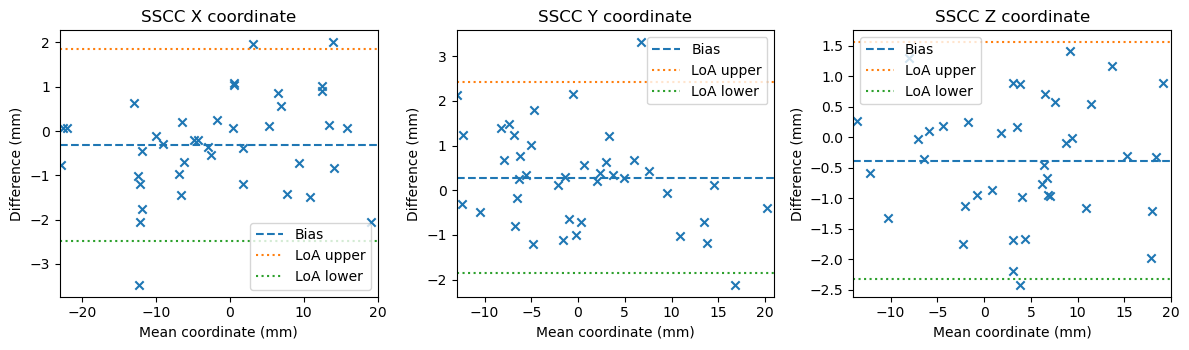

In [2]:
# the stats functions
import numpy as np
import matplotlib.pyplot as plt

def bland_altman_basic(ob1, ob2, ax=None, title="Bland–Altman", xlab="Mean", ylab="Diff"):
    """
    Basic Bland–Altman for 1D paired data.
    Draws bias and limits of agreement (±1.96*SD). Returns (fig, ax).
    """
    ob1 = np.asarray(ob1, float).ravel()
    ob2 = np.asarray(ob2, float).ravel()
    if ob1.size != ob2.size or ob1.size < 3:
        raise ValueError("Need >=3 paired observations with equal length.")

    mean_ob = (ob1 + ob2) / 2.0
    diff_ob = ob1 - ob2
    bias = np.mean(diff_ob)
    sd   = np.std(diff_ob, ddof=1)
    loa_upper = bias + 1.96 * sd
    loa_lower = bias - 1.96 * sd

    created = False
    if ax is None:
        fig, ax = plt.subplots()
        created = True
    else:
        fig = ax.figure

    ax.scatter(mean_ob, diff_ob, marker='x')          # keep default colors
    x_min, x_max = np.floor(mean_ob.min()), np.ceil(mean_ob.max())
    ax.plot([x_min, x_max], [bias, bias], linestyle='--', label="Bias")
    ax.plot([x_min, x_max], [loa_upper, loa_upper], linestyle=':', label="LoA upper")
    ax.plot([x_min, x_max], [loa_lower, loa_lower], linestyle=':', label="LoA lower")
    ax.set_xlim(x_min, x_max)
    y_min = min(diff_ob.min(), loa_lower)
    y_max = max(diff_ob.max(), loa_upper)
    pad = 0.05 * max(1.0, (y_max - y_min))
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend()
    return fig, ax


def bland_altman_3d_per_axis(pts1_mm, pts2_mm, roi_name="ROI"):
    """
    Basic per-axis Bland–Altman for 3D landmarks.
    pts*_mm: arrays of shape (N, 3) in millimetres, matched point-wise.
    Returns (fig, axes).
    """
    pts1_mm = np.asarray(pts1_mm, float)
    pts2_mm = np.asarray(pts2_mm, float)
    if pts1_mm.shape != pts2_mm.shape or pts1_mm.ndim != 2 or pts1_mm.shape[1] != 3:
        raise ValueError("pts1_mm and pts2_mm must be (N, 3) arrays.")

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    labels = ["X", "Y", "Z"]

    for i, lab in enumerate(labels):
        bland_altman_basic(
            pts1_mm[:, i],
            pts2_mm[:, i],
            ax=axes[i],
            title=f"{roi_name} {lab} coordinate",
            xlab="Mean coordinate (mm)",
            ylab="Difference (mm)",
        )
    fig.tight_layout()
    return fig, axes

# ---- tiny example ----
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    # fake 3D points (N,3)
    p1 = rng.normal(0, 10, size=(40, 3))
    p2 = p1 + np.array([0.4, -0.2, 0.6]) + rng.normal(0, 1.0, size=(40, 3))
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="SSCC")
    plt.show()


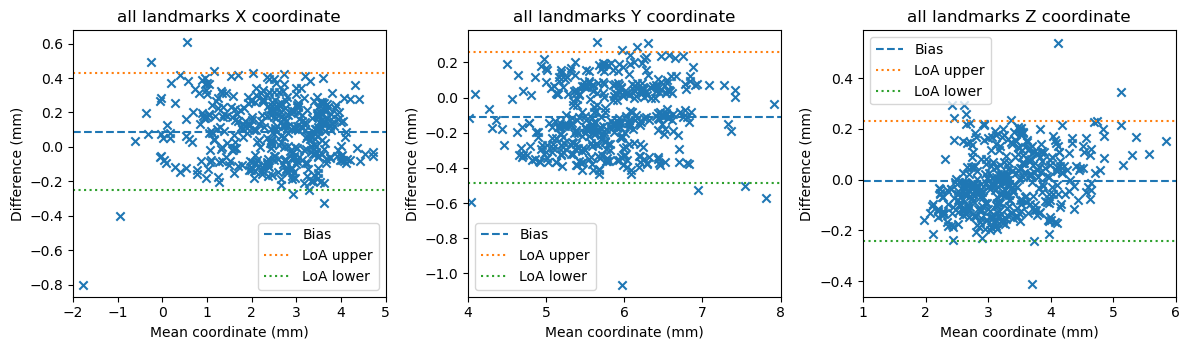

In [4]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = down_net_FC_y_test_true[:, 1, :] * 0.15
    p2 = down_net_FC_y_test_pred[:, 1, :] * 0.15
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="all landmarks")
    plt.show()

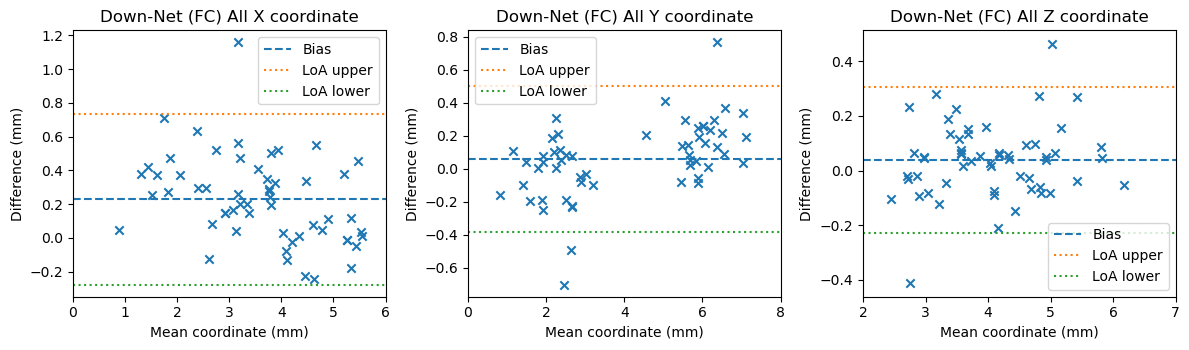

In [32]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = down_net_FC_y_CTPre14_true.reshape(-1, 3) * 0.15
    p2 = down_net_FC_y_CTPre14_pred.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="Down-Net (FC) All")
    plt.show()

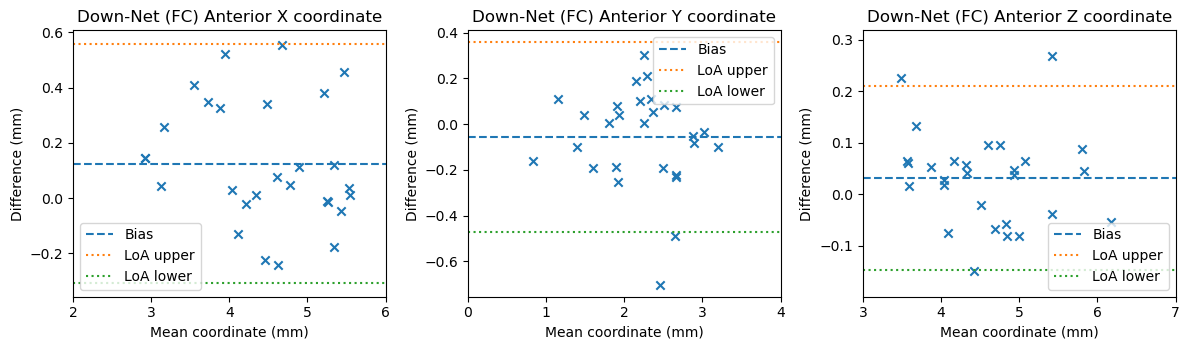

In [29]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = down_net_FC_y_CTPre14_true[:, 0] * 0.15
    p2 = down_net_FC_y_CTPre14_pred[:, 0] * 0.15
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="Down-Net (FC) Anterior")
    plt.show()

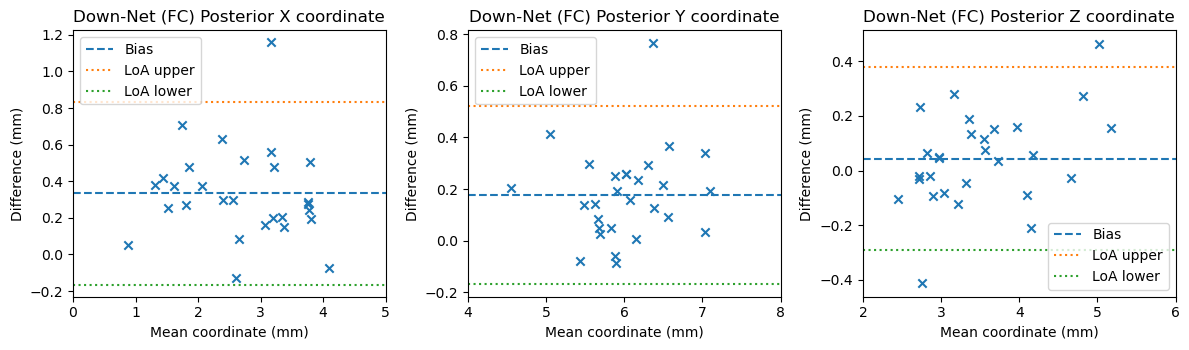

In [31]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = down_net_FC_y_CTPre14_true[:, 1] * 0.15
    p2 = down_net_FC_y_CTPre14_pred[:, 1] * 0.15
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="Down-Net (FC) Posterior")
    plt.show()

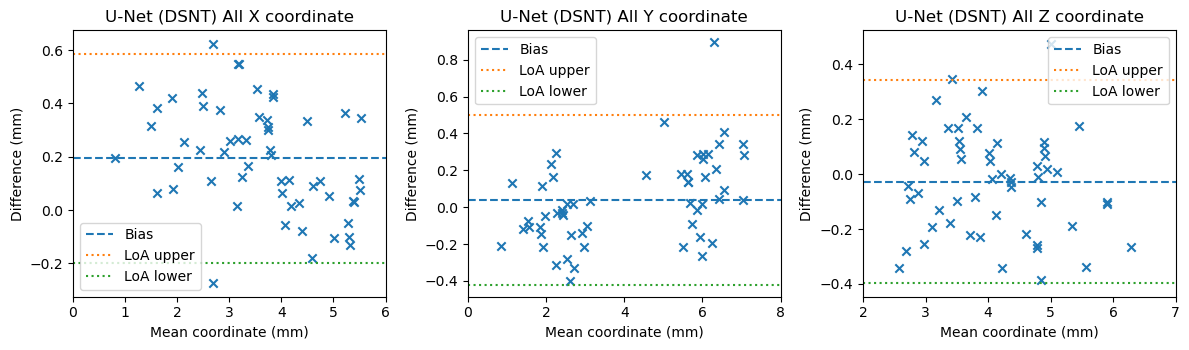

In [28]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = u_net_DSNT_y_CTPre14_true_015.reshape(-1, 3) * 0.15
    p2 = u_net_DSNT_y_CTPre14_pred_015.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="U-Net (DSNT) All")
    plt.show()

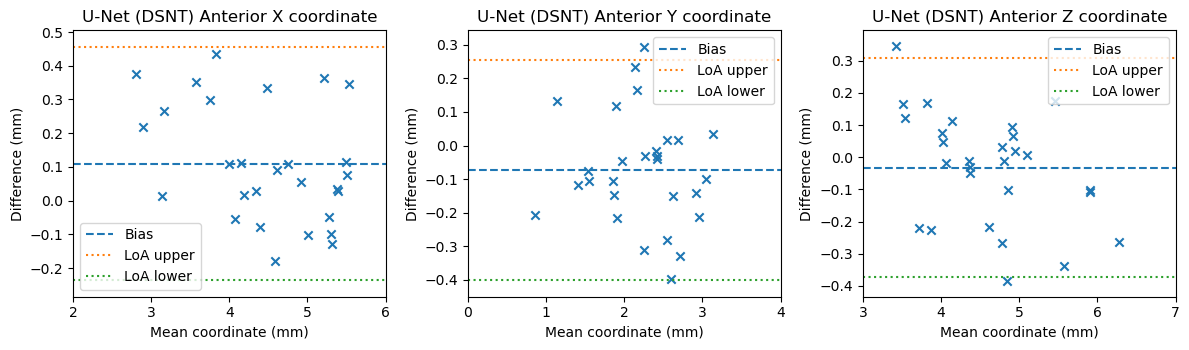

In [34]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = u_net_DSNT_y_CTPre14_true_015[:, 0] * 0.15
    p2 = u_net_DSNT_y_CTPre14_pred_015[:, 0] * 0.15
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="U-Net (DSNT) Anterior")
    plt.show()

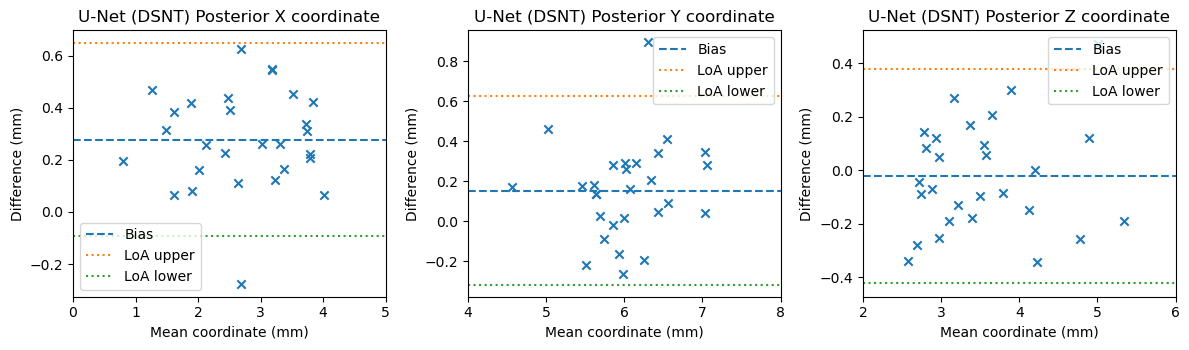

In [35]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = u_net_DSNT_y_CTPre14_true_015[:, 1] * 0.15
    p2 = u_net_DSNT_y_CTPre14_pred_015[:, 1] * 0.15
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="U-Net (DSNT) Posterior")
    plt.show()

### Confidence intervals

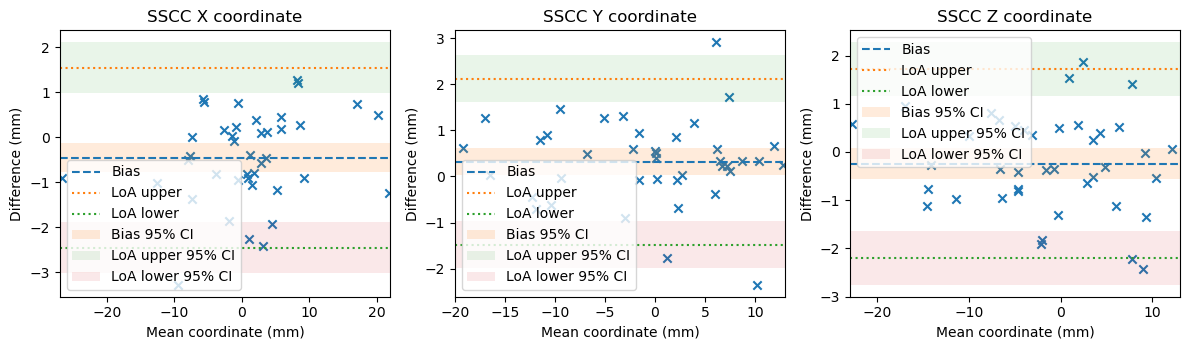

In [ ]:
# the stats function
import numpy as np
import matplotlib.pyplot as plt

def _tcrit(df: int, alpha: float = 0.05) -> float:
    """Two-sided t critical value; falls back to ~1.96 if SciPy not installed."""
    try:
        from scipy.stats import t
        return float(t.ppf(1 - alpha/2, df))
    except Exception:
        return 1.96  # Normal approx

def bland_altman_with_ci(
    ob1,
    ob2,
    ax=None,
    title="Bland–Altman (with 95% CIs)",
    xlabel="Mean of methods",
    ylabel="Difference (ob1 − ob2)",
    loa_z: float = 1.96,         # 95% LoA
    alpha: float = 0.05,         # 95% CI bands
):
    """
    Basic Bland–Altman plot with shaded 95% CIs for bias and LoA.

    Parameters
    ----------
    ob1, ob2 : array-like (1D, same length)
        Paired measurements from two methods.
    ax : matplotlib Axes, optional
    loa_z : float
        Z multiplier for LoA (1.96 → ~95%).
    alpha : float
        CI level for shaded bands (0.05 → 95% CI).

    Returns
    -------
    fig, ax, stats : (Figure, Axes, dict)
        stats contains bias, sd, loa_lower/upper and CI bounds.
    """
    x = np.asarray(ob1, float).ravel()
    y = np.asarray(ob2, float).ravel()
    if x.size != y.size or x.size < 3:
        raise ValueError("Need ≥3 paired observations of equal length.")
    n = x.size
    df = n - 1

    mean_ob = (x + y) / 2.0
    diff_ob = x - y

    bias = float(np.mean(diff_ob))
    sd   = float(np.std(diff_ob, ddof=1))
    loa_lower = bias - loa_z * sd
    loa_upper = bias + loa_z * sd

    # CIs (Bland & Altman 1999)
    tcrit = _tcrit(df, alpha=alpha)
    se_bias = sd / np.sqrt(n)
    se_loa = sd * np.sqrt(1.0/n + (loa_z**2) / (2*(n-1)))

    bias_ci = (bias - tcrit*se_bias, bias + tcrit*se_bias)
    loa_lower_ci = (loa_lower - tcrit*se_loa, loa_lower + tcrit*se_loa)
    loa_upper_ci = (loa_upper - tcrit*se_loa, loa_upper + tcrit*se_loa)

    created = False
    if ax is None:
        fig, ax = plt.subplots()
        created = True
    else:
        fig = ax.figure

    # Scatter
    ax.scatter(mean_ob, diff_ob, marker="x")  # (no explicit colors)

    # Horizontal lines
    x_min, x_max = np.floor(mean_ob.min()), np.ceil(mean_ob.max())
    xx = np.array([x_min, x_max], float)
    ax.plot(xx, [bias, bias], linestyle="--", label="Bias")
    ax.plot(xx, [loa_upper, loa_upper], linestyle=":", label="LoA upper")
    ax.plot(xx, [loa_lower, loa_lower], linestyle=":", label="LoA lower")

    # Shaded CI bands
    ax.fill_between(xx, bias_ci[0], bias_ci[1], alpha=0.15, label="Bias 95% CI")
    ax.fill_between(xx, loa_upper_ci[0], loa_upper_ci[1], alpha=0.10, label="LoA upper 95% CI")
    ax.fill_between(xx, loa_lower_ci[0], loa_lower_ci[1], alpha=0.10, label="LoA lower 95% CI")

    # Axes, labels
    y_min = min(diff_ob.min(), loa_lower_ci[0])
    y_max = max(diff_ob.max(), loa_upper_ci[1])
    pad = 0.05 * max(1.0, (y_max - y_min))
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

    stats = dict(
        n=n, bias=bias, sd=sd,
        loa_lower=loa_lower, loa_upper=loa_upper,
        bias_ci=bias_ci, loa_lower_ci=loa_lower_ci, loa_upper_ci=loa_upper_ci,
    )
    return fig, ax, stats


# ---------- Optional: per-axis 3D helper (simple) ----------

def bland_altman_3d_per_axis_with_ci(pts1_mm, pts2_mm, roi_name="ROI"):
    """
    Per-axis BA with 95% CI bands for 3D landmarks.
    pts*_mm: arrays (N, 3) in millimetres.
    """
    pts1_mm = np.asarray(pts1_mm, float)
    pts2_mm = np.asarray(pts2_mm, float)
    if pts1_mm.shape != pts2_mm.shape or pts1_mm.ndim != 2 or pts1_mm.shape[1] != 3:
        raise ValueError("pts1_mm and pts2_mm must be (N, 3) arrays.")

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    for i, lab in enumerate(["X", "Y", "Z"]):
        bland_altman_with_ci(
            pts1_mm[:, i],
            pts2_mm[:, i],
            ax=axes[i],
            title=f"{roi_name} {lab} coordinate",
            xlabel="Mean coordinate (mm)",
            ylabel="Difference (mm)"
        )
    fig.tight_layout()
    return fig, axes


# ---- tiny demo ----
if __name__ == "__main__":
    rng = np.random.default_rng(1)
    p1 = rng.normal(0, 10, size=(40, 3))
    p2 = p1 + np.array([0.4, -0.2, 0.6]) + rng.normal(0, 1.0, size=(40, 3))
    fig, axes = bland_altman_3d_per_axis_with_ci(p1, p2, roi_name="LSCC")
    plt.show()


{'n': 40, 'bias': 0.1887986110433551, 'sd': 1.0181354524069817, 'loa_lower': -1.806746875674329, 'loa_upper': 2.184344097761039, 'bias_ci': (np.float64(-0.13681690350976405), np.float64(0.5144141255964743)), 'loa_lower_ci': (np.float64(-2.3679073369122836), np.float64(-1.2455864144363744)), 'loa_upper_ci': (np.float64(1.6231836365230845), np.float64(2.7455045589989937))}


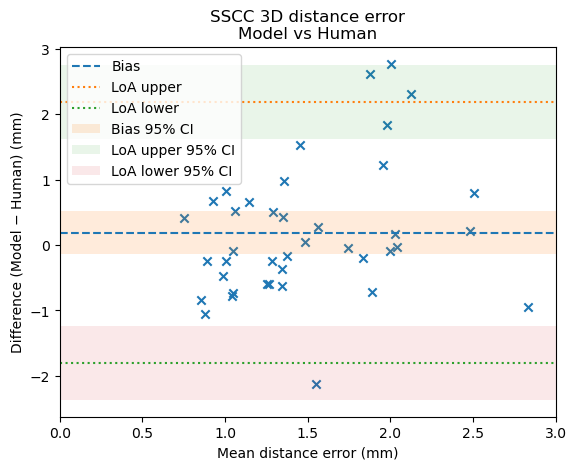

In [7]:
# add per distance Bland–Altman plots with CIs
def bland_altman_3d_distance_with_ci(
    ref_pts_mm,
    pts1_mm,
    pts2_mm,
    roi_name: str = "ROI",
    method1_label: str = "Method 1",
    method2_label: str = "Method 2",
):
    """
    Bland–Altman on 3D *distance errors* for landmarks.

    Parameters
    ----------
    ref_pts_mm : (N, 3)
        Reference landmarks (e.g. ground truth) in mm.
    pts1_mm : (N, 3)
        Landmarks from method 1 (e.g. model predictions) in mm.
    pts2_mm : (N, 3)
        Landmarks from method 2 (e.g. human annotations, baseline model) in mm.

    Returns
    -------
    fig, ax, stats
        BA figure, axis and stats dict from bland_altman_with_ci.
    """
    ref_pts_mm = np.asarray(ref_pts_mm, float)
    pts1_mm    = np.asarray(pts1_mm, float)
    pts2_mm    = np.asarray(pts2_mm, float)

    if ref_pts_mm.shape != pts1_mm.shape or ref_pts_mm.shape != pts2_mm.shape:
        raise ValueError("ref_pts_mm, pts1_mm, pts2_mm must all be (N,3) with same shape.")

    if ref_pts_mm.ndim != 2 or ref_pts_mm.shape[1] != 3:
        raise ValueError("Expected (N,3) arrays for landmarks in mm.")

    # 3D Euclidean distance errors to the reference (per landmark)
    err1 = np.linalg.norm(pts1_mm - ref_pts_mm, axis=1)
    err2 = np.linalg.norm(pts2_mm - ref_pts_mm, axis=1)

    title = f"{roi_name} 3D distance error\n{method1_label} vs {method2_label}"
    xlabel = "Mean distance error (mm)"
    ylabel = f"Difference ({method1_label} − {method2_label}) (mm)"

    fig, ax, stats = bland_altman_with_ci(
        err1,
        err2,
        ax=None,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
    )
    return fig, ax, stats

# ---- tiny demo ----
if __name__ == "__main__":
    rng = np.random.default_rng(1)
    n = 40

    # Fake ground truth landmarks
    ref = rng.normal(0, 10, size=(n, 3))

    # Method 1: slightly biased + noise
    pts1 = ref + np.array([0.4, -0.2, 0.6]) + rng.normal(0, 1.0, size=(n, 3))

    # Method 2: different bias + noise
    pts2 = ref + np.array([0.1, 0.0, 0.3]) + rng.normal(0, 1.0, size=(n, 3))

    fig, ax, stats = bland_altman_3d_distance_with_ci(
        ref, pts1, pts2,
        roi_name="SSCC",
        method1_label="Model",
        method2_label="Human"
    )
    print(stats)
    plt.show()


{'n': 28, 'bias': 0.2873589970527867, 'sd': 0.19102540238062146, 'loa_lower': -0.08705079161323132, 'loa_upper': 0.6617687857188048, 'bias_ci': (np.float64(0.21328707873069547), np.float64(0.361430915374878)), 'loa_lower_ci': (np.float64(-0.21517467277639246), np.float64(0.04107308954992983)), 'loa_upper_ci': (np.float64(0.5336449045556437), np.float64(0.7898926668819659))}


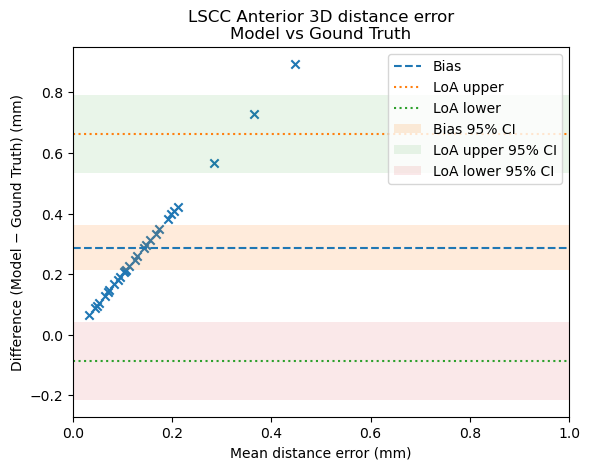

In [9]:
if __name__ == "__main__":
    # ground truth landmarks
    ref_ant = y_CTPre14_true[:, 0, :] * 0.15
    ref_pos = y_CTPre14_true[:, 1, :] * 0.15

    # Method 1: model predictions
    model_ant = y_CTPre14_pred[:, 0, :] * 0.15
    model_pos = y_CTPre14_pred[:, 1, :] * 0.15

    # Method 2: just the reference (perfect)

    fig, ax, stats = bland_altman_3d_distance_with_ci(
        ref_ant, model_ant, ref_ant,
        roi_name="LSCC Anterior",
        method1_label="Model",
        method2_label="Gound Truth"
    )
    print(stats)
    plt.show()


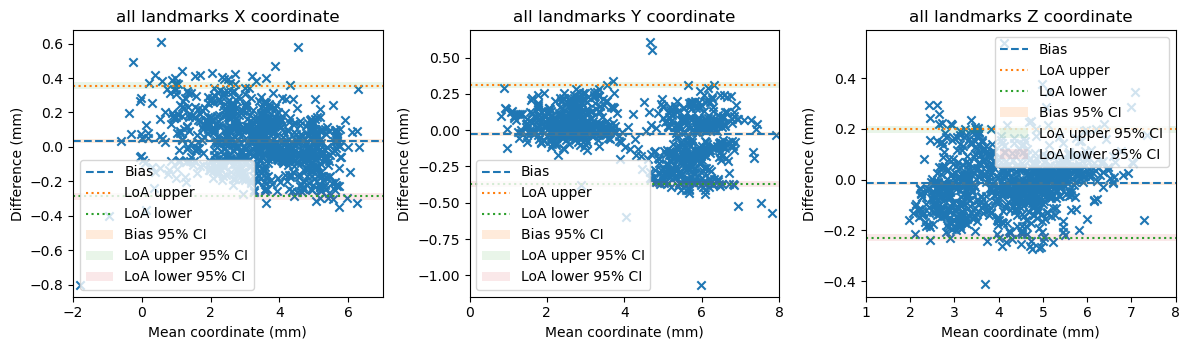

In [6]:
if __name__ == "__main__":
    p1 = y_test_true.reshape(-1, 3) * 0.15
    p2 = y_test_pred.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis_with_ci(p1, p2, roi_name="all landmarks")
    plt.show()

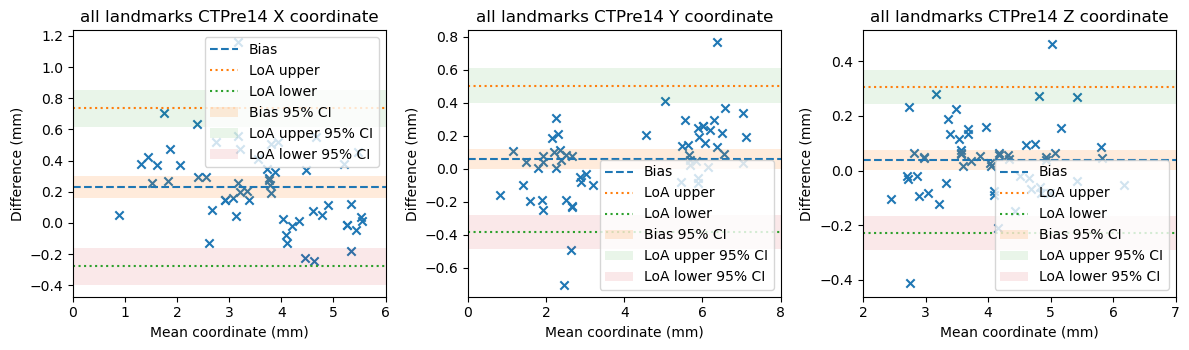

In [ ]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = y_CTPre14_true.reshape(-1, 3) * 0.15
    p2 = y_CTPre14_pred.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis_with_ci(p1, p2, roi_name="ndmarks CTPre14")
    plt.show()  

## TRE (Target Registration Error)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


In [5]:
def compute_tre(expert_coords: np.ndarray,
                model_coords: np.ndarray) -> pd.Series:
    """
    Compute TRE (Euclidean distance) between model and expert landmarks.

    Parameters
    ----------
    expert_coords : (N, 3) array
    model_coords  : (N, 3) array

    Returns
    -------
    summary : pandas.Series
        Contains per-point TRE as well as summary statistics.
    """
    expert_coords = np.asarray(expert_coords)
    model_coords  = np.asarray(model_coords)
    assert expert_coords.shape == model_coords.shape
    assert expert_coords.shape[1] == 3, "Expect shape (N, 3) for xyz"

    # per-case TRE (Euclidean distance)
    tre = np.linalg.norm(model_coords - expert_coords, axis=1)  # shape (N,)

    summary = pd.Series({
        "N": len(tre),
        "mean_TRE_mm": tre.mean(),
        "std_TRE_mm": tre.std(ddof=1),
        "median_TRE_mm": np.median(tre),
        "p95_TRE_mm": np.percentile(tre, 95),
        "max_TRE_mm": tre.max(),
    })

    return tre, summary

In [ ]:
expert_coords_all = y_CTPre14_true.reshape(-1, 3) * 0.15
model_coords_all = y_CTPre14_pred.reshape(-1, 3) * 0.15

In [15]:
tre, tre_summary = compute_tre(expert_coords_all, model_coords_all)
print(tre_summary)

N                56.000000
mean_TRE_mm       0.375112
std_TRE_mm        0.227333
median_TRE_mm     0.322808
p95_TRE_mm        0.768398
max_TRE_mm        1.264364
dtype: float64


## Bland–Altman Analysis (per axis)

In [6]:
def bland_altman_stats(expert: np.ndarray,
                       model: np.ndarray) -> dict:
    """
    Compute Bland–Altman statistics between expert and model for 1D data.

    Parameters
    ----------
    expert : (N,) array
    model  : (N,) array

    Returns
    -------
    stats : dict
        mean_diff, loa_lower, loa_upper, sd_diff
    """
    expert = np.asarray(expert)
    model  = np.asarray(model)
    diff   = model - expert
    mean_diff = diff.mean()
    sd_diff   = diff.std(ddof=1)
    loa_lower = mean_diff - 1.96 * sd_diff
    loa_upper = mean_diff + 1.96 * sd_diff

    return {
        "mean_diff": mean_diff,
        "sd_diff": sd_diff,
        "loa_lower": loa_lower,
        "loa_upper": loa_upper,
    }


def bland_altman_plot(expert: np.ndarray,
                      model: np.ndarray,
                      axis_name: str = "X"):
    """
    Make a Bland–Altman plot for one coordinate axis.
    """
    expert = np.asarray(expert)
    model  = np.asarray(model)
    mean_vals = (expert + model) / 2.0
    diff      = model - expert

    stats_ba = bland_altman_stats(expert, model)

    plt.figure()
    plt.scatter(mean_vals, diff, alpha=0.7)
    plt.axhline(stats_ba["mean_diff"], linestyle='-')
    plt.axhline(stats_ba["loa_lower"], linestyle='--')
    plt.axhline(stats_ba["loa_upper"], linestyle='--')
    plt.xlabel(f"Mean of Expert and Model ({axis_name} coord, mm)")
    plt.ylabel(f"Difference (Model - Expert) ({axis_name}, mm)")
    plt.title(f"Bland–Altman Plot ({axis_name}-axis)")
    plt.tight_layout()
    plt.show()

    return stats_ba


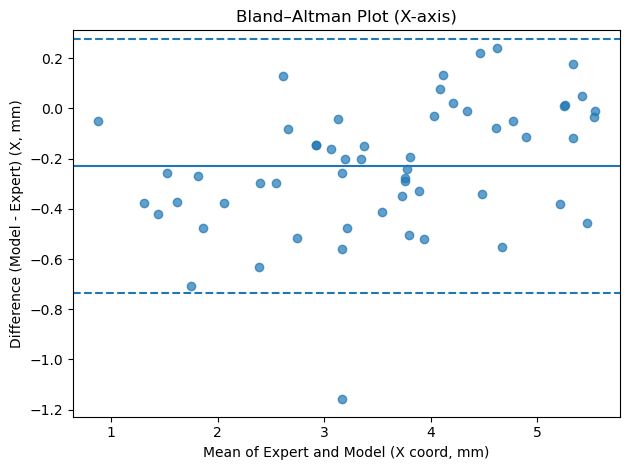

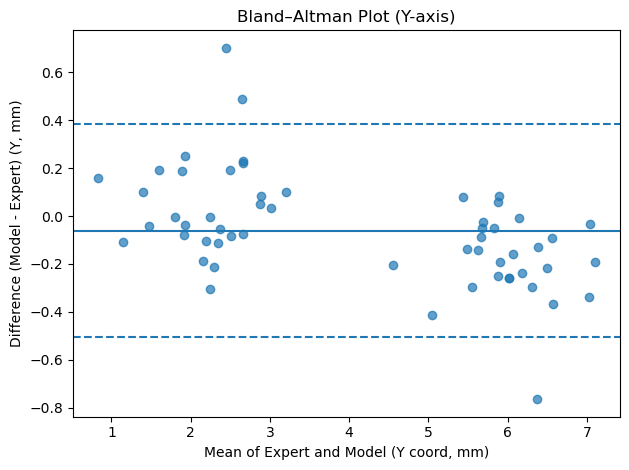

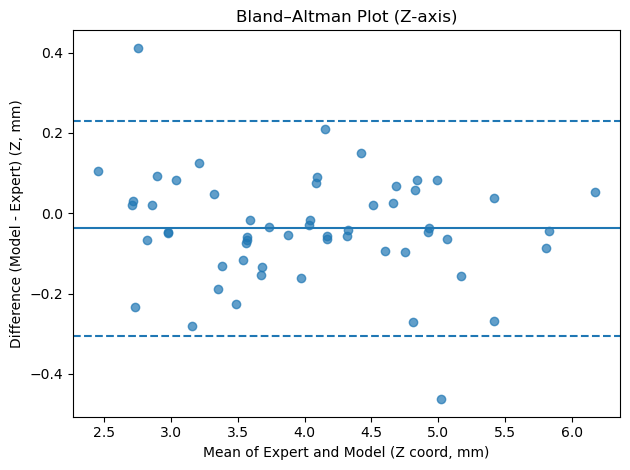

Bland–Altman X: {'mean_diff': np.float32(-0.22930257), 'sd_diff': np.float32(0.2582801), 'loa_lower': np.float32(-0.73553157), 'loa_upper': np.float32(0.2769264)}
Bland–Altman Y: {'mean_diff': np.float32(-0.060328186), 'sd_diff': np.float32(0.22582264), 'loa_lower': np.float32(-0.50294054), 'loa_upper': np.float32(0.3822842)}
Bland–Altman Z: {'mean_diff': np.float32(-0.03770759), 'sd_diff': np.float32(0.13621445), 'loa_lower': np.float32(-0.30468792), 'loa_upper': np.float32(0.22927272)}


In [17]:
x_exp, y_exp, z_exp = expert_coords_all[:,0], expert_coords_all[:,1], expert_coords_all[:,2]
x_mod, y_mod, z_mod = model_coords_all[:,0], model_coords_all[:,1], model_coords_all[:,2]

ba_x = bland_altman_plot(x_exp, x_mod, axis_name="X")
ba_y = bland_altman_plot(y_exp, y_mod, axis_name="Y")
ba_z = bland_altman_plot(z_exp, z_mod, axis_name="Z")

print("Bland–Altman X:", ba_x)
print("Bland–Altman Y:", ba_y)
print("Bland–Altman Z:", ba_z)


## TOST Equivalence Test on Mean TRE

In [7]:
def tost_equivalence_onesample(x: np.ndarray,
                               delta: float,
                               alpha: float = 0.05):
    """
    One-sample TOST for equivalence of mean(x) to 0 within margin [-delta, +delta].

    Parameters
    ----------
    x : (N,) array
        Sample values, e.g. TRE in mm.
    delta : float
        Equivalence margin in same units (e.g. 0.5 mm).
    alpha : float
        Significance level.

    Returns
    -------
    results : dict
        Contains t1, p1, t2, p2, p_TOST, mean, ci_low, ci_high, equivalent (bool)
    """
    x = np.asarray(x)
    n  = len(x)
    mean_x = x.mean()
    sd_x   = x.std(ddof=1)
    se_x   = sd_x / np.sqrt(n)
    df     = n - 1

    # Test 1: H0: μ ≤ -δ  vs  H1: μ > -δ
    t1 = (mean_x - (-delta)) / se_x
    p1 = 1 - stats.t.cdf(t1, df=df)  # one-sided

    # Test 2: H0: μ ≥ +δ  vs  H1: μ < +δ
    t2 = (mean_x - delta) / se_x
    p2 = stats.t.cdf(t2, df=df)      # one-sided

    # TOST p-value is max of the two one-sided p-values
    p_tost = max(p1, p2)

    # 100*(1-2α)% CI for mean
    ci_low, ci_high = stats.t.interval(
        confidence=1 - 2*alpha,
        df=df,
        loc=mean_x,
        scale=se_x
    )

    equivalent = p_tost < alpha

    return {
        "mean": mean_x,
        "sd": sd_x,
        "n": n,
        "delta": delta,
        "alpha": alpha,
        "t1": t1, "p1": p1,
        "t2": t2, "p2": p2,
        "p_TOST": p_tost,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "equivalent": equivalent,
    }


In [21]:
# Suppose 0.5 mm is your clinical equivalence margin
delta = 0.5
tost_res = tost_equivalence_onesample(tre, delta=delta, alpha=0.05)

print(pd.Series(tost_res))


mean           0.375112
sd             0.227333
n                    56
delta               0.5
alpha              0.05
t1            28.806828
p1                  0.0
t2            -4.111034
p2             0.000066
p_TOST         0.000066
ci_low         0.324288
ci_high        0.425937
equivalent         True
dtype: object


## TOST on Median

In [36]:
import numpy as np
import pandas as pd
from scipy.stats import t, wilcoxon
from typing import Optional


def _tcrit(df: int, alpha: float = 0.05) -> float:
    """Two-sided t critical value for CI (kept for reference)."""
    try:
        return float(t.ppf(1 - alpha / 2, df))
    except Exception:
        return 1.96


# === NEW: one-sided parametric test (mean < delta) ===
def onesided_ttest_mean_less(x, delta: float = 0.5, alpha: float = 0.05) -> pd.Series:
    """
    One-sided one-sample t-test on the mean of x.

    Hypotheses
    ----------
    H0: mean(x) >= delta
    H1: mean(x) <  delta

    Parameters
    ----------
    x : array-like
        1D array of observations (e.g. per-ear or per-patient TRE).
    delta : float
        Threshold (e.g. 0.5 mm).
    alpha : float
        Significance level.

    Returns
    -------
    pandas.Series with:
        mean, sd, n, delta, alpha, t_stat, p_value,
        ci_upper (one-sided 100*(1-alpha)% upper CI for mean),
        passes (True if p < alpha).
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    df = n - 1

    # t statistic (centered at delta)
    # if mean << delta => t is negative and large in magnitude
    t_stat = (mean - delta) / se

    # one-sided: H1: mean < delta → left-tail
    p_value = t.cdf(t_stat, df=df)

    # one-sided upper (1 - alpha) CI for mean
    # mean + t_(1-alpha, df) * SE
    tcrit_one_sided = float(t.ppf(1 - alpha, df))
    ci_upper = mean + tcrit_one_sided * se

    passes = bool(p_value < alpha)

    return pd.Series({
        "mean": mean,
        "sd": sd,
        "n": n,
        "delta": delta,
        "alpha": alpha,
        "t_stat": t_stat,
        "p_value": p_value,
        "ci_upper": ci_upper,
        "mean_less_than_delta": passes,
    })


# === NEW: one-sided Wilcoxon (median < delta) ===
def onesided_wilcoxon_median_less(x, delta: float = 0.5, alpha: float = 0.05) -> pd.Series:
    """
    One-sided Wilcoxon signed-rank test on the median of x.

    Hypotheses
    ----------
    H0: median(x) >= delta
    H1: median(x) <  delta

    Implemented by testing the differences d = x - delta
    with alternative="less" (we expect negative differences).

    Parameters
    ----------
    x : array-like
        1D array of observations (e.g. per-ear or per-patient TRE).
    delta : float
        Threshold (e.g. 0.5 mm).
    alpha : float
        Significance level.

    Returns
    -------
    pandas.Series with:
        median, n, delta, alpha,
        wilcoxon_stat, p_value,
        median_less_than_delta (True if p < alpha).
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    med = float(np.median(x))

    # Differences relative to delta
    d = x - delta

    # H1: median(x) < delta  <=> median(d) < 0  -> alternative="less"
    w_res = wilcoxon(d, alternative="less", zero_method="wilcox")
    stat, p_value = w_res.statistic, w_res.pvalue

    passes = bool(p_value < alpha)

    return pd.Series({
        "median": med,
        "n": n,
        "delta": delta,
        "alpha": alpha,
        "wilcoxon_stat": stat,
        "p_value": p_value,
        "median_less_than_delta": passes,
    })


def compute_tre_summary_and_tests(
    expert_coords: np.ndarray,
    model_coords: np.ndarray,
    delta: float = 0.5,
    alpha: float = 0.05,
    group: Optional[np.ndarray] = None,
):
    """
    Compute TRE summary + one-sided tests vs delta.

    - TRE is always a Euclidean distance (>= 0).
    - We only care whether TRE is sufficiently small:
        H0: mean/median >= delta
        H1: mean/median <  delta

    Parameters
    ----------
    expert_coords, model_coords : array (N, 3)
        Landmark coordinates (same shape).
    group : array of shape (N,), optional
        Group ID for each landmark.
        - None: use individual landmarks (TRE per landmark)
        - array: average TRE within each group (ear or patient)

    Returns
    -------
    dict with:
      - tre_summary        : distribution summary of TRE (at chosen level)
      - ttest_one_sided    : one-sided t-test result (mean < delta)
      - wilcoxon_one_sided : one-sided Wilcoxon result (median < delta)
      - tre_values_used    : 1D TRE values used for testing
      - group_used         : "landmark" or "grouped"
    """
    expert_coords = np.asarray(expert_coords)
    model_coords  = np.asarray(model_coords)
    assert expert_coords.shape == model_coords.shape
    assert expert_coords.ndim == 2 and expert_coords.shape[1] == 3

    # Landmark-level TRE
    tre_landmark = np.linalg.norm(model_coords - expert_coords, axis=1)

    if group is None:
        tre = tre_landmark
        group_used = "landmark"
    else:
        group = np.asarray(group)
        assert group.shape[0] == tre_landmark.shape[0], "group size mismatch"

        # Average within each group (ear or patient)
        tre = np.array([
            tre_landmark[group == g].mean()
            for g in np.unique(group)
        ])
        group_used = "grouped"

    # Summary stats (including IQR)
    q1 = float(np.percentile(tre, 25))
    q3 = float(np.percentile(tre, 75))
    iqr = q3 - q1

    tre_summary = pd.Series({
        "N": float(tre.size),
        "mean_TRE_mm": float(tre.mean()),
        "std_TRE_mm": float(tre.std(ddof=1)),
        "median_TRE_mm": float(np.median(tre)),
        "Q1_TRE_mm": q1,
        "Q3_TRE_mm": q3,
        "IQR_TRE_mm": iqr,
        "min_TRE_mm": float(tre.min()), 
        "p95_TRE_mm": float(np.percentile(tre, 95)),
        "max_TRE_mm": float(tre.max()),
        "percent_TRE_le_0.5_mm": float((tre <= 0.5).mean() * 100),
    })

    # One-sided tests vs delta
    ttest_one_sided    = onesided_ttest_mean_less(tre, delta=delta, alpha=alpha)
    wilcoxon_one_sided = onesided_wilcoxon_median_less(tre, delta=delta, alpha=alpha)

    return {
        "tre_summary": tre_summary,
        "ttest_one_sided": ttest_one_sided,
        "wilcoxon_one_sided": wilcoxon_one_sided,
        "tre_values_used": tre,
        "group_used": group_used,
    }


In [37]:
# for all the landmarks
model_coords_all = down_net_FC_y_CTPre14_pred.reshape(-1, 3) * 0.15
expert_coords_all   = down_net_FC_y_CTPre14_true.reshape(-1, 3) * 0.15

res_ear = compute_tre_summary_and_tests(
    expert_coords_all,    # (28, 2, 3)
    model_coords_all,     # (28, 2, 3)
    delta=0.5,
    alpha=0.05,
)

print("*** tre summary ***")
print(res_ear["tre_summary"])
print("*** TOST parametric ***")
print(res_ear["ttest_one_sided"])
print("*** TOST wilcoxon ***")
print(res_ear["wilcoxon_one_sided"])


*** tre summary ***
N                        56.000000
mean_TRE_mm               0.375112
std_TRE_mm                0.227333
median_TRE_mm             0.322808
Q1_TRE_mm                 0.219043
Q3_TRE_mm                 0.493432
IQR_TRE_mm                0.274388
min_TRE_mm                0.064810
p95_TRE_mm                0.768398
max_TRE_mm                1.264364
percent_TRE_le_0.5_mm    75.000000
dtype: float64
*** TOST parametric ***
mean                    0.375112
sd                      0.227333
n                             56
delta                        0.5
alpha                       0.05
t_stat                 -4.111034
p_value                 0.000066
ci_upper                0.425937
mean_less_than_delta        True
dtype: object
*** TOST wilcoxon ***
median                    0.322808
n                               56
delta                          0.5
alpha                         0.05
wilcoxon_stat                302.0
p_value                   0.000026
median_less_t

In [38]:
# for all the landmarks
model_coords_all = u_net_DSNT_y_CTPre14_pred_015.reshape(-1, 3) * 0.15
expert_coords_all   = u_net_DSNT_y_CTPre14_true_015.reshape(-1, 3) * 0.15

res_ear = compute_tre_summary_and_tests(
    expert_coords_all,    # (28, 2, 3)
    model_coords_all,     # (28, 2, 3)
    delta=0.5,
    alpha=0.05,
)

print("*** tre summary ***")
print(res_ear["tre_summary"])
print("*** TOST parametric ***")
print(res_ear["ttest_one_sided"])
print("*** TOST wilcoxon ***")
print(res_ear["wilcoxon_one_sided"])

*** tre summary ***
N                        56.000000
mean_TRE_mm               0.378216
std_TRE_mm                0.159546
median_TRE_mm             0.377293
Q1_TRE_mm                 0.241956
Q3_TRE_mm                 0.474201
IQR_TRE_mm                0.232245
min_TRE_mm                0.120095
p95_TRE_mm                0.634651
max_TRE_mm                0.903283
percent_TRE_le_0.5_mm    76.785714
dtype: float64
*** TOST parametric ***
mean                    0.378216
sd                      0.159546
n                             56
delta                        0.5
alpha                       0.05
t_stat                 -5.712142
p_value                      0.0
ci_upper                0.413886
mean_less_than_delta        True
dtype: object
*** TOST wilcoxon ***
median                    0.377293
n                               56
delta                          0.5
alpha                         0.05
wilcoxon_stat                221.0
p_value                   0.000001
median_less_t

In [12]:
# for ant the landmarks
model_coords_ant = down_net_FC_y_CTPre14_pred[:, 0] * 0.15
expert_coords_ant   = down_net_FC_y_CTPre14_true[:, 0] * 0.15

res_ear = compute_tre_summary_and_tost(
    expert_coords_ant,    # (28, 2, 3)
    model_coords_ant,     # (28, 2, 3)
    delta=0.5,
    alpha=0.05,
)

print("*** tre summary ***")
print(res_ear["tre_summary"])
print("*** TOST parametric ***")
print(res_ear["tost_parametric"])
print("*** TOST wilcoxon ***")
print(res_ear["tost_wilcoxon"])


*** tre summary ***
N                        28.000000
mean_TRE_mm               0.287359
std_TRE_mm                0.191025
median_TRE_mm             0.237672
p95_TRE_mm                0.671751
max_TRE_mm                0.893627
percent_TRE_le_0.5_mm    89.285714
dtype: float64
*** TOST parametric ***
mean           0.287359
sd             0.191025
n                    28
delta               0.5
alpha              0.05
t1            21.810252
p1                  0.0
t2            -5.890266
p2             0.000001
p_TOST         0.000001
ci_low         0.213287
ci_high        0.361431
equivalent         True
dtype: object
*** TOST wilcoxon ***
median                 0.237672
n                            28
delta                       0.5
alpha                      0.05
wilcoxon_stat_lower       406.0
p1_lower                    0.0
wilcoxon_stat_upper        36.0
p2_upper               0.000018
p_TOST                 0.000018
equivalent                 True
dtype: object


In [13]:
# for ant the landmarks
model_coords_pos = down_net_FC_y_CTPre14_pred[:, 1] * 0.15
expert_coords_pos   = down_net_FC_y_CTPre14_true[:, 1] * 0.15

res_ear = compute_tre_summary_and_tost(
    expert_coords_pos,    # (28, 2, 3)
    model_coords_pos,     # (28, 2, 3)
    delta=0.5,
    alpha=0.05,
)

print("*** tre summary ***")
print(res_ear["tre_summary"])
print("*** TOST parametric ***")
print(res_ear["tost_parametric"])
print("*** TOST wilcoxon ***")
print(res_ear["tost_wilcoxon"])

*** tre summary ***
N                        28.000000
mean_TRE_mm               0.462866
std_TRE_mm                0.229809
median_TRE_mm             0.403980
p95_TRE_mm                0.780197
max_TRE_mm                1.264364
percent_TRE_le_0.5_mm    60.714286
dtype: float64
*** TOST parametric ***
mean           0.462866
sd             0.229809
n                    28
delta               0.5
alpha              0.05
t1            22.170611
p1                  0.0
t2            -0.855041
p2             0.200026
p_TOST         0.200026
ci_low         0.373755
ci_high        0.551976
equivalent        False
dtype: object
*** TOST wilcoxon ***
median                  0.40398
n                            28
delta                       0.5
alpha                      0.05
wilcoxon_stat_lower       406.0
p1_lower                    0.0
wilcoxon_stat_upper       140.0
p2_upper               0.078455
p_TOST                 0.078455
equivalent                False
dtype: object


## all four landmarks separately

In [34]:
# for donw-net

landmarks = ["LLSCC ant", "LLSCC pos", "RLSCC ant", "RLSCC pos"]

down_net_FC_y_CTPre14_pred_reshape = down_net_FC_y_CTPre14_pred.reshape(14, 2, 2, 3)
down_net_FC_y_CTPre14_true_reshape = down_net_FC_y_CTPre14_true.reshape(14, 2, 2, 3)

model_coords_lant = down_net_FC_y_CTPre14_pred_reshape[:, 0, 0, :] * 0.15
expert_coords_lant = down_net_FC_y_CTPre14_true_reshape[:, 0, 0, :] * 0.15

model_coords_lpos = down_net_FC_y_CTPre14_pred_reshape[:, 0, 1, :] * 0.15
expert_coords_lpos = down_net_FC_y_CTPre14_true_reshape[:, 0, 1, :] * 0.15

model_coords_rant = down_net_FC_y_CTPre14_pred_reshape[:, 1, 0, :] * 0.15
expert_coords_rant = down_net_FC_y_CTPre14_true_reshape[:, 1, 0, :] * 0.15

model_coords_rpos = down_net_FC_y_CTPre14_pred_reshape[:, 1, 1, :] * 0.15
expert_coords_rpos = down_net_FC_y_CTPre14_true_reshape[:, 1, 1, :] * 0.15

res_lant = compute_tre_summary_and_tests(
    expert_coords_lant,    # (28, 2, 3)
    model_coords_lant,     # (28, 2, 3)
    delta=0.5,
    alpha=0.05,
)

res_lpos = compute_tre_summary_and_tests(
    expert_coords_lpos,    # (28, 2, 3)
    model_coords_lpos,     # (28, 2, 3)
    delta=0.5,
    alpha=0.05,
)

res_rant = compute_tre_summary_and_tests(
    expert_coords_rant,    # (28, 2, 3)
    model_coords_rant,     # (28, 2, 3)
    delta=0.5,
    alpha=0.05,
)

res_rpos = compute_tre_summary_and_tests(
    expert_coords_rpos,    # (28, 2, 3)
    model_coords_rpos,     # (28, 2, 3)
    delta=0.5,
    alpha=0.05,
)
print("landmarks stats for: ", landmarks[0])
print("*** tre summary ***")
print(res_lant["tre_summary"])
print("*** TOST parametric ***")
print(res_lant["ttest_one_sided"])
print("*** TOST wilcoxon ***")
print(res_lant["wilcoxon_one_sided"])
print("*" * 15)

print("landmarks stats for: ", landmarks[1])
print("*** tre summary ***")
print(res_lpos["tre_summary"])
print("*** TOST parametric ***")
print(res_lpos["ttest_one_sided"])
print("*** TOST wilcoxon ***")
print(res_lpos["wilcoxon_one_sided"])
print("*" * 15)

print("landmarks stats for: ", landmarks[2])
print("*** tre summary ***")
print(res_rant["tre_summary"])
print("*** TOST parametric ***")
print(res_rant["ttest_one_sided"])
print("*** TOST wilcoxon ***")
print(res_rant["wilcoxon_one_sided"])
print("*" * 15)

print("landmarks stats for: ", landmarks[3])
print("*** tre summary ***")
print(res_rpos["tre_summary"])
print("*** TOST parametric ***")
print(res_rpos["ttest_one_sided"])
print("*** TOST wilcoxon ***")
print(res_rpos["wilcoxon_one_sided"])
print("*" * 15)

landmarks stats for:  LLSCC ant
*** tre summary ***
N                        14.000000
mean_TRE_mm               0.302559
std_TRE_mm                0.216013
median_TRE_mm             0.253639
Q1_TRE_mm                 0.172001
Q3_TRE_mm                 0.344705
IQR_TRE_mm                0.172705
p95_TRE_mm                0.681807
max_TRE_mm                0.893627
percent_TRE_le_0.5_mm    85.714286
dtype: float64
*** TOST parametric ***
mean                    0.302559
sd                      0.216013
n                             14
delta                        0.5
alpha                       0.05
t_stat                 -3.419962
p_value                 0.002282
ci_upper                0.404799
mean_less_than_delta        True
dtype: object
*** TOST wilcoxon ***
median                    0.253639
n                               14
delta                          0.5
alpha                         0.05
wilcoxon_stat                 13.0
p_value                   0.005371
median_less_than

In [35]:
# for u-net dsnt

landmarks = ["LLSCC ant", "LLSCC pos", "RLSCC ant", "RLSCC pos"]

u_net_DSNT_y_CTPre14_pred_reshape = u_net_DSNT_y_CTPre14_pred_015.reshape(14, 2, 2, 3)
u_net_DSNT_y_CTPre14_true_reshape = u_net_DSNT_y_CTPre14_true_015.reshape(14, 2, 2, 3)

model_coords_lant = u_net_DSNT_y_CTPre14_pred_reshape[:, 0, 0, :] * 0.15
expert_coords_lant = u_net_DSNT_y_CTPre14_true_reshape[:, 0, 0, :] * 0.15

model_coords_lpos = u_net_DSNT_y_CTPre14_pred_reshape[:, 0, 1, :] * 0.15
expert_coords_lpos = u_net_DSNT_y_CTPre14_true_reshape[:, 0, 1, :] * 0.15

model_coords_rant = u_net_DSNT_y_CTPre14_pred_reshape[:, 1, 0, :] * 0.15
expert_coords_rant = u_net_DSNT_y_CTPre14_true_reshape[:, 1, 0, :] * 0.15

model_coords_rpos = u_net_DSNT_y_CTPre14_pred_reshape[:, 1, 1, :] * 0.15
expert_coords_rpos = u_net_DSNT_y_CTPre14_true_reshape[:, 1, 1, :] * 0.15

res_lant = compute_tre_summary_and_tests(
    expert_coords_lant,    # (28, 2, 3)
    model_coords_lant,     # (28, 2, 3)
    delta=0.5,
    alpha=0.05,
)

res_lpos = compute_tre_summary_and_tests(
    expert_coords_lpos,    # (28, 2, 3)
    model_coords_lpos,     # (28, 2, 3)
    delta=0.5,
    alpha=0.05,
)

res_rant = compute_tre_summary_and_tests(
    expert_coords_rant,    # (28, 2, 3)
    model_coords_rant,     # (28, 2, 3)
    delta=0.5,
    alpha=0.05,
)

res_rpos = compute_tre_summary_and_tests(
    expert_coords_rpos,    # (28, 2, 3)
    model_coords_rpos,     # (28, 2, 3)
    delta=0.5,
    alpha=0.05,
)
print("landmarks stats for: ", landmarks[0])
print("*** tre summary ***")
print(res_lant["tre_summary"])
print("*** TOST parametric ***")
print(res_lant["ttest_one_sided"])
print("*** TOST wilcoxon ***")
print(res_lant["wilcoxon_one_sided"])
print("*" * 15)

print("landmarks stats for: ", landmarks[1])
print("*** tre summary ***")
print(res_lpos["tre_summary"])
print("*** TOST parametric ***")
print(res_lpos["ttest_one_sided"])
print("*** TOST wilcoxon ***")
print(res_lpos["wilcoxon_one_sided"])
print("*" * 15)

print("landmarks stats for: ", landmarks[2])
print("*** tre summary ***")
print(res_rant["tre_summary"])
print("*** TOST parametric ***")
print(res_rant["ttest_one_sided"])
print("*** TOST wilcoxon ***")
print(res_rant["wilcoxon_one_sided"])
print("*" * 15)

print("landmarks stats for: ", landmarks[3])
print("*** tre summary ***")
print(res_rpos["tre_summary"])
print("*** TOST parametric ***")
print(res_rpos["ttest_one_sided"])
print("*** TOST wilcoxon ***")
print(res_rpos["wilcoxon_one_sided"])
print("*" * 15)

landmarks stats for:  LLSCC ant
*** tre summary ***
N                        14.000000
mean_TRE_mm               0.300419
std_TRE_mm                0.109975
median_TRE_mm             0.324857
Q1_TRE_mm                 0.209470
Q3_TRE_mm                 0.373883
IQR_TRE_mm                0.164413
p95_TRE_mm                0.442309
max_TRE_mm                0.533822
percent_TRE_le_0.5_mm    92.857143
dtype: float64
*** TOST parametric ***
mean                    0.300419
sd                      0.109975
n                             14
delta                        0.5
alpha                       0.05
t_stat                 -6.790334
p_value                 0.000006
ci_upper                 0.35247
mean_less_than_delta        True
dtype: object
*** TOST wilcoxon ***
median                    0.324857
n                               14
delta                          0.5
alpha                         0.05
wilcoxon_stat                  1.0
p_value                   0.000122
median_less_than

## % Within Clinical Tolerance

In [8]:
def percent_within_threshold(tre: np.ndarray, threshold: float) -> float:
    """
    Percentage of cases with TRE <= threshold.
    """
    tre = np.asarray(tre)
    return 100.0 * np.mean(tre <= threshold)


In [38]:
print("Percent TRE <= 0.6 mm:", percent_within_threshold(tre, 0.5), "%")
print("Percent TRE <= 1.0 mm:", percent_within_threshold(tre, 1.0), "%")


Percent TRE <= 0.6 mm: 75.0 %
Percent TRE <= 1.0 mm: 98.21428571428571 %


In [10]:
def evaluate_model_vs_expert(expert_coords, model_coords,
                             clinical_delta=0.5):
    # 1) TRE
    tre, tre_summary = compute_tre(expert_coords, model_coords)
    print("TRE summary:")
    print(tre_summary, "\n")

    # 2) % within clinically acceptable threshold
    pct_05 = percent_within_threshold(tre, clinical_delta)
    print(f"% of cases with TRE <= {clinical_delta} mm:", pct_05, "%\n")

    # 3) TOST on mean TRE
    tost_res = tost_equivalence_onesample(tre, delta=clinical_delta, alpha=0.05)
    print("TOST result:")
    print(pd.Series(tost_res), "\n")

    # 4) Bland–Altman for X, Y, Z
    x_exp, y_exp, z_exp = expert_coords[:,0], expert_coords[:,1], expert_coords[:,2]
    x_mod, y_mod, z_mod = model_coords[:,0], model_coords[:,1], model_coords[:,2]

    # print("Bland–Altman X:")
    # print(bland_altman_plot(x_exp, x_mod, axis_name="X"), "\n")

    # print("Bland–Altman Y:")
    # print(bland_altman_plot(y_exp, y_mod, axis_name="Y"), "\n")

    # print("Bland–Altman Z:")
    # print(bland_altman_plot(z_exp, z_mod, axis_name="Z"), "\n")

    return tre, tre_summary, tost_res

# Example call (assuming you already have expert_coords, model_coords as (N, 3))
# tre, tre_summary, tost_res = evaluate_model_vs_expert(expert_coords, model_coords, clinical_delta=0.5)


## stats for down net FC

In [13]:
# all landmarks CTPre14
down_net_FC_true_all = down_net_FC_y_CTPre14_true.reshape(-1, 3) * 0.15
down_net_FC_pred_all = down_net_FC_y_CTPre14_pred.reshape(-1, 3) * 0.15
# anterior only
down_net_FC_true_ant = down_net_FC_y_CTPre14_true[:, 0, :] * 0.15
down_net_FC_pred_ant = down_net_FC_y_CTPre14_pred[:, 0, :] * 0.15
# posterior only
down_net_FC_true_pos = down_net_FC_y_CTPre14_true[:, 1, :] * 0.15
down_net_FC_pred_pos = down_net_FC_y_CTPre14_pred[:, 1, :] * 0.15

print("*** Down-Net (FC) all landmarks ***")
tre_down_net_FC_all, tre_summary_down_net_FC_all, tost_res_down_net_FC_all = evaluate_model_vs_expert(down_net_FC_pred_all, down_net_FC_true_all, clinical_delta=0.5)
print("*** Down-Net (FC) anterior landmarks ***")
tre_down_net_FC_ant, tre_summary_down_net_FC_ant, tost_res_down_net_FC_ant = evaluate_model_vs_expert(down_net_FC_pred_ant, down_net_FC_true_ant, clinical_delta=0.5)
print("*** Down-Net (FC) posterior landmarks ***")
tre_down_net_FC_pos, tre_summary_down_net_FC_pos, tost_res_down_net_FC_pos = evaluate_model_vs_expert(down_net_FC_pred_pos, down_net_FC_true_pos, clinical_delta=0.5)

*** Down-Net (FC) all landmarks ***
TRE summary:
N                56.000000
mean_TRE_mm       0.375112
std_TRE_mm        0.227333
median_TRE_mm     0.322808
p95_TRE_mm        0.768398
max_TRE_mm        1.264364
dtype: float64 

% of cases with TRE <= 0.5 mm: 75.0 %

TOST result:
mean           0.375112
sd             0.227333
n                    56
delta               0.5
alpha              0.05
t1            28.806828
p1                  0.0
t2            -4.111034
p2             0.000066
p_TOST         0.000066
ci_low         0.324288
ci_high        0.425937
equivalent         True
dtype: object 

*** Down-Net (FC) anterior landmarks ***
TRE summary:
N                28.000000
mean_TRE_mm       0.287359
std_TRE_mm        0.191025
median_TRE_mm     0.237672
p95_TRE_mm        0.671751
max_TRE_mm        0.893627
dtype: float64 

% of cases with TRE <= 0.5 mm: 89.28571428571429 %

TOST result:
mean           0.287359
sd             0.191025
n                    28
delta               0.

## stats for u_net DSNT

In [14]:
# all landmarks CTPre14
u_net_DSNT_true_all = u_net_DSNT_y_CTPre14_true_015.reshape(-1, 3) * 0.15
u_net_DSNT_pred_all = u_net_DSNT_y_CTPre14_pred_015.reshape(-1, 3) * 0.15
# anterior only
u_net_DSNT_true_ant = u_net_DSNT_y_CTPre14_true_015[:, 0, :] * 0.15
u_net_DSNT_pred_ant = u_net_DSNT_y_CTPre14_pred_015[:, 0, :] * 0.15
# posterior only
u_net_DSNT_true_pos = u_net_DSNT_y_CTPre14_true_015[:, 1, :] * 0.15
u_net_DSNT_pred_pos = u_net_DSNT_y_CTPre14_pred_015[:, 1, :] * 0.15 

print("*** U-Net (DSNT) all landmarks ***")
tre_u_net_DSNT_all, tre_summary_u_net_DSNT_all, tost_res_u_net_DSNT_all = evaluate_model_vs_expert(u_net_DSNT_pred_all, u_net_DSNT_true_all, clinical_delta=0.5)
print("*** U-Net (DSNT) anterior landmarks ***")
tre_u_net_DSNT_ant, tre_summary_u_net_DSNT_ant, tost_res_u_net_DSNT_ant = evaluate_model_vs_expert(u_net_DSNT_pred_ant, u_net_DSNT_true_ant, clinical_delta=0.5)
print("*** U-Net (DSNT) posterior landmarks ***")
tre_u_net_DSNT_pos, tre_summary_u_net_DSNT_pos, tost_res_u_net_DSNT_pos = evaluate_model_vs_expert(u_net_DSNT_pred_pos, u_net_DSNT_true_pos, clinical_delta=0.5)

*** U-Net (DSNT) all landmarks ***
TRE summary:
N                56.000000
mean_TRE_mm       0.378216
std_TRE_mm        0.159546
median_TRE_mm     0.377293
p95_TRE_mm        0.634651
max_TRE_mm        0.903283
dtype: float64 

% of cases with TRE <= 0.5 mm: 76.78571428571429 %

TOST result:
mean           0.378216
sd             0.159546
n                    56
delta               0.5
alpha              0.05
t1            41.191807
p1                  0.0
t2            -5.712142
p2                  0.0
p_TOST              0.0
ci_low         0.342547
ci_high        0.413886
equivalent         True
dtype: object 

*** U-Net (DSNT) anterior landmarks ***
TRE summary:
N                28.000000
mean_TRE_mm       0.299068
std_TRE_mm        0.124732
median_TRE_mm     0.287778
p95_TRE_mm        0.503246
max_TRE_mm        0.533822
dtype: float64 

% of cases with TRE <= 0.5 mm: 92.85714285714286 %

TOST result:
mean           0.299068
sd             0.124732
n                    28
delta      